<span style='font-size:x-large'>**Trends in U.S. Cities Hazard Identification and Climate Initiatives in CDP Reporting \(2019\-2023\)**</span>

<span style='font-size:medium'>**YEDS Capstone Project 2026 | Anna Brause**</span>

**Project Overview**

As climate change accelerates, cities are on the frontlines of managing environmental hazards as they are home to 55% of the world's population, a figure that is projected to reach 68% by 2050 \([United Nations](https://www.un.org/sw/desa/68-world-population-projected-live-urban-areas-2050-says-un?utm_source=chatgpt.com), 2018\). Municipal governments are tasked with identifying hazards, assessing vulnerability, and implementing adaptation programs, all while navigating competing budget pressures, shifting federal priorities, and unexpected disruptions like the COVID\-19 pandemic. Understanding how cities are actually performing on climate change related issues and identifying any trends associated with hazard identification and climate adaptation planning over time is critical for informing more effective urban climate policy and protecting the large populations who call these cities home. 

This project analyzes five years of Carbon Disclosure Project \(CDP\) Cities Survey data from 18 of the most populous U.S. cities to examine how climate risk assessments, hazard identification, and adaptation program implementation has evolved from 2019 to 2023. The CPD Cities Survey is one of the most comprehensive standardized frameworks through which cities voluntarily disclose their climate risks and actions, making it a valuable tool for tracking municipal climate progress over time. 

**Research Questions**

1. How have urban climate risk assessments, hazard reporting, and adaptation programs changed across major U.S. cities from 2019 to 2023?
2. Did the COVID\-19 pandemic measurable affect municipal climate risk reporting and adaptation efforts?
3. How do city size, population density, and primary hazard type influence the implementation of climate risk assessments and adaptation programs?

**Data Source**

- **Dataset:** CDP Cities Survey Response Data \(2019\-2023\)
- **Source:** Carbon Disclosure Project \(CDP\) Open Data Portal
- **Coverage:** 18 most populous U.S. cities, 5 annual reporting cycles \(Note: the original dataset includes hundreds of major global cities, and my analysis began with 20 U.S. cities, but two removed during the initial cleaning process due to insufficient response data across the reporting period.\)
- **Unit of Analysis:** City\-year \(90 observations total\). This means each row in the dataset represents one city in one reporting year. \(18 cities observed across 5 years produces 90 total records.\)
- **Key Variables:** Climate risk assessment completion status, number of hazards identified, most common hazard type, number of adaptation programs, city population \(2023\), land area \(2023\), and population density \(2023\). 
- **Note on population and land area:** Raw DCP survey data contained missing population and land area values for most cities in 2019\-2022, as cities reported inconsistently across years. To address this, 2023 values \- the most recent and complete year available \- were extracted and applied uniformly across all reporting years via a left join on city name. Population density was then recalculated as population divided by land area \(residents per sq km\). This standardization is appropriate because population and land area are relatively stable city\-level characteristics across the five\-year window examined, and using a single reference year avoids introducing inconsistencies from patchwork data across multiple sources. 

**Analytical Goals**

- Track trends in climate risk assessment completion and hazard identification across cities from 2019\-2023
- Examine how adaptation program implementation has changed over time and whether it responds to hazard identification
- Explore whether the COVID\-19 pandemic influenced climate reporting and adaptation metrics
- Analyze how city size, population density, and hazard type relate to adaptation program implementation
- Apply statistical methods including correlation, linear regression, and ANOVA to test relationships between key variables

**Methods Summary**

This analysis is conducted entirely in R using the dplyr and ggplot2 packages. The workflow proceeds through four stages: data loading and inspection, data cleaning and standardization, exploratory data analysis, and formal statistical analysis with visualization. All code is documented and reproducible from the provided dataset. 



In [3]:
# Load libraries
library(dplyr)
library(ggplot2)

# Set plot theme similar to seaborn whitegrid
theme_set(theme_minimal())


Attaching package: ‘dplyr’




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [4]:
# Create data frame by reading in data
df <- read.csv("capstone_city_climate_data.csv")
class(df)

[1] "data.frame"

In [6]:
# View data summary
head(df)
str(df)
summary(df)

,city,climate_risk_assessment_YN,CDP_response_year,num_hazards,most_common_hazard,population,population_year,land_area_sqkm,num_adapt_programs,pop_density
,<chr>,<chr>,<int>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,New York,Yes,2019,5,Flood and sea level rise,NA,NA,NA,7,NA
2,Los Angeles,Yes,2019,6,Flood and sea level rise,NA,NA,NA,8,NA
3,Chicago,Yes,2019,6,Extreme Precipitation,NA,NA,NA,1,NA
4,Houston,No,2019,6,Extreme heat,NA,NA,NA,7,NA
5,Phoenix,Yes,2019,5,Extreme heat,NA,NA,NA,NA,NA
6,Philadelphia,Yes,2019,4,Extreme cold,NA,NA,NA,4,NA


'data.frame':	90 obs. of  10 variables:
 $ city                      : chr  "New York" "Los Angeles" "Chicago" "Houston" ...
 $ climate_risk_assessment_YN: chr  "Yes" "Yes" "Yes" "No" ...
 $ CDP_response_year         : int  2019 2019 2019 2019 2019 2019 2019 2019 2019 2019 ...
 $ num_hazards               : num  5 6 6 6 5 4 5 NA 4 5 ...
 $ most_common_hazard        : chr  "Flood and sea level rise" "Flood and sea level rise" "Extreme Precipitation" "Extreme heat" ...
 $ population                : num  NA NA NA NA NA NA NA NA NA NA ...
 $ population_year           : num  NA NA NA NA NA NA NA NA NA NA ...
 $ land_area_sqkm            : num  NA NA NA NA NA NA NA NA NA NA ...
 $ num_adapt_programs        : num  7 8 1 7 NA 4 4 NA 5 3 ...
 $ pop_density               : num  NA NA NA NA NA NA NA NA NA NA ...


     city           climate_risk_assessment_YN CDP_response_year
 Length:90          Length:90                  Min.   :2019     
 Class :character   Class :character           1st Qu.:2020     
 Mode  :character   Mode  :character           Median :2021     
                                               Mean   :2021     
                                               3rd Qu.:2022     
                                               Max.   :2023     
                                                                
  num_hazards    most_common_hazard   population      population_year
 Min.   :2.000   Length:90          Min.   : 713252   Min.   :2020   
 1st Qu.:4.000   Class :character   1st Qu.: 900386   1st Qu.:2021   
 Median :5.000   Mode  :character   Median :1292958   Median :2022   
 Mean   :4.708                      Mean   :1836252   Mean   :2021   
 3rd Qu.:6.000                      3rd Qu.:1636839   3rd Qu.:2022   
 Max.   :9.000                      Max.   :8804190   Max.  

The raw CDP survey data contained missing population and land area values for most cities in 2019–2022, as cities reported these figures inconsistently across years. To create a clean, standardized dataset, 2023 population and land area values were extracted and backfilled across all prior years using a left join on city name. Population density was then recalculated uniformly as population divided by land area. This approach is appropriate because these are stable city\-level characteristics that do not change meaningfully over a five\-year window.


In [8]:
# Extract static 2023 population and land area
pop_2023 <- df %>%
  filter(CDP_response_year == 2023) %>%
  select(city, population, land_area_sqkm) %>%
  rename(population_2023 = population,
         land_area_2023 = land_area_sqkm)

# Join back and fill missing values
df <- df %>%
  left_join(pop_2023, by = "city") %>%
  mutate(
    population = coalesce(population, population_2023),
    land_area_sqkm = coalesce(land_area_sqkm, land_area_2023),
    pop_density = population / land_area_sqkm
  ) %>%
  select(-population_2023, -land_area_2023)

In [9]:
# Check which years are included
table(df$CDP_response_year)

# Check key variables exist
names(df)

# Check 2023 population and land area values applied
df %>%
  filter(CDP_response_year == 2023) %>%
  select(city, population, land_area_sqkm, pop_density) %>%
  head(10)


2019 2020 2021 2022 2023 
  18   18   18   18   18 

[1] "city"                       "climate_risk_assessment_YN"
 [3] "CDP_response_year"          "num_hazards"               
 [5] "most_common_hazard"         "population"                
 [7] "population_year"            "land_area_sqkm"            
 [9] "num_adapt_programs"         "pop_density"

,city,population,land_area_sqkm,pop_density
,<chr>,<dbl>,<dbl>,<dbl>
1,New York,8804190,778.0,11316.4396
2,Los Angeles,3766109,1218.0,3092.0435
3,Chicago,2696555,587.0,4593.7905
4,Houston,2288250,1740.0,1315.0862
5,Phoenix,1657035,1347.0,1230.1670
6,Philadelphia,1576251,348.0,4529.4569
7,San Antonio,1472909,1200.0,1227.4242
8,San Diego,1382000,332.0,4162.6506
9,Austin,1297458,1823.0,711.7159


<span style='font-size:medium'>**Data Cleaning**</span>

The raw datasets contained missing values for population and land area across most reporting years. To simplify and standardize city\-level characteristics, 2023 \(most current usable CDP Cities Survey data set\) population and land area values were used as a consistent baseline across all years. These values were backfilled into 2019\-2022 rows \(left\_join on city name\) and population density was calculated uniformly as population divided by land area \(people per sq km\) using these standardized values. This approach was chosen because population and land area are relatively stable city characteristics across the five\-year window examined


In [10]:
# Standardize climate_risk_assessment_YN as a factor
df$climate_risk_assessment_YN <- as.factor(df$climate_risk_assessment_YN)

# Standardize most_common_hazard — fix any minor inconsistencies
df$most_common_hazard <- trimws(df$most_common_hazard)

# Make CDP_response_year a factor for grouping plots
df$CDP_response_year <- as.integer(df$CDP_response_year)

# Check for remaining NAs in key columns
colSums(is.na(df))

city climate_risk_assessment_YN 
                         0                          0 
         CDP_response_year                num_hazards 
                         0                          1 
        most_common_hazard                 population 
                         0                          0 
           population_year             land_area_sqkm 
                        72                          0 
        num_adapt_programs                pop_density 
                         2                          0

<span style='font-size:medium'>**Exploratory Data Analytics \(EDA\)**</span>

Before conducting the formal analysis and visualization for my Capstone Project, I examined the distributions and spread of key variables to understand the shape of my data, identify outliers, and inform appropriate statistical methods. The histograms below show the overall distribution of hazard counts and adaptation programs across all cities and years analyzed. The boxplots show how these distributions changed year over year, revealing not just average trends, but also variability across cities. 

These exploratory visualizations help establish whether the data are normally distributed, whether outliers are present that could influence statistical results, and whether year\-over\-year variability is consistent or shifting, all of which inform the interpretation of the formal analysis that follows.


Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_bin()`).”


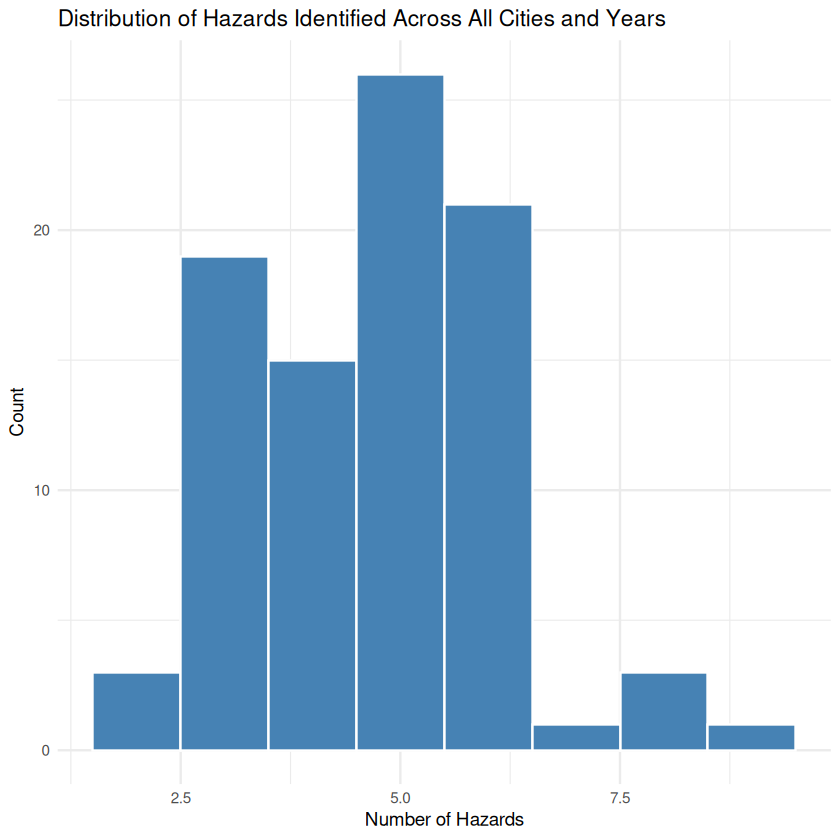

In [11]:
# Exploratory Data Analytics (EDA)
# Distribution of number of hazards (num_hazards)
ggplot(df, aes(x = num_hazards)) +
  geom_histogram(binwidth = 1, fill = "steelblue", color = "white") +
  labs(
    title = "Distribution of Hazards Identified Across All Cities and Years",
    x = "Number of Hazards",
    y = "Count"
  ) +
  theme_minimal()

**Interpretation:** The distribution of hazards identified across all cities and years is centered around 5, which represents the most frequently occurring value with approximately 32 city\-year records. The distribution is left\-skewed, with a notable concentration of observations at 3 and 5–6 hazards and a thinner tail at the lower end near 2. Very few city\-years report more than 7 hazards, with only ~4 observations at 7 or above. The spread from 2 to 8 hazards suggests moderate variability in how many hazards cities formally identify, though the majority fall within a consistent 4–6 range.


Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_bin()`).”


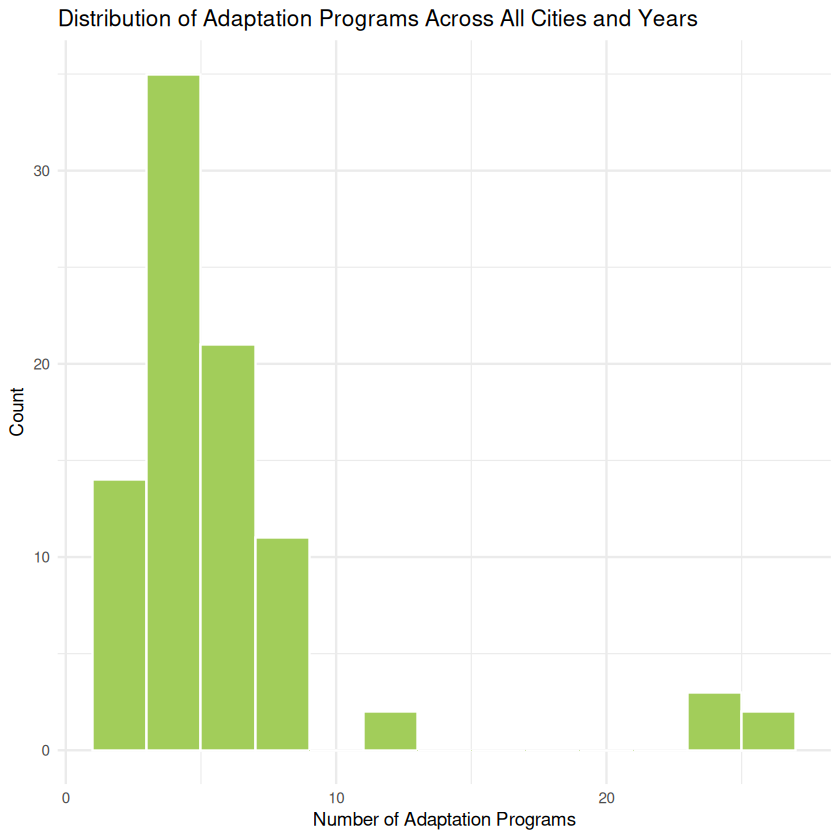

In [27]:
# Distribution of adaptation programs
ggplot(df, aes(x = num_adapt_programs)) +
  geom_histogram(binwidth = 2, fill = "darkolivegreen3", color = "white") +
  labs(
    title = "Distribution of Adaptation Programs Across All Cities and Years",
    x = "Number of Adaptation Programs",
    y = "Count"
  ) +
  theme_minimal()

**Interpretation:** The distribution of adaptation programs is left\-skewed, with most city\-years reporting between 1 and 9 programs but outliers exist toward higher counts. A notable outlier exists near 24\-26 programs, likely corresponding to Columbus, Ohio, which consistently reported unusually high adaptation program counts across multiple years. This skew and presence of outliers should be kept in mind when interpreting mean\-based comparisons throughout the analysis. 


## 2.1 Spread of hazards dipped in 2022 and shifted from physical risk to regulatory risk

Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”


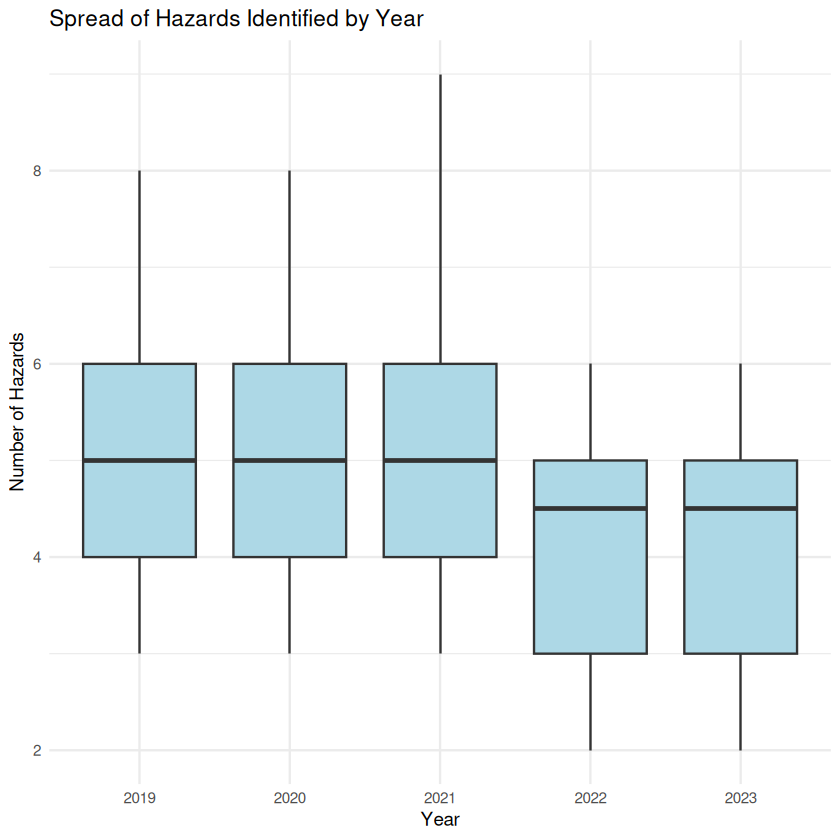

In [28]:
# Boxplot: hazards by year to show spread
ggplot(df, aes(x = as.factor(CDP_response_year), y = num_hazards)) +
  geom_boxplot(fill = "lightblue") +
  labs(
    title = "Spread of Hazards Identified by Year",
    x = "Year",
    y = "Number of Hazards"
  ) +
  theme_minimal()

**Interpretation:** The boxplots show that hazard identification was relatively consistent from 2019 to 2021, with medians at 5 and similar interquartile ranges spanning roughly 4 to 6 hazards. A notable shift occurs in 2022 and 2023, where the median drops to approximately 4.5 and the spread ranging from 3 to 5 hazards, with the upper whisker pulling in significantly. Importantly, the 2021 upper whisker extends to 9, the highest observed value in the dataset, just before the sharp decline, suggesting 2021 may represent a peak in hazard reporting before a broad\-based consolidation/decline. This visual pattern is later confirmed by the time\-trend regression analysis, which finds the decline statistically significant \(p = 0.010\).


Warning message:
“Removed 2 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


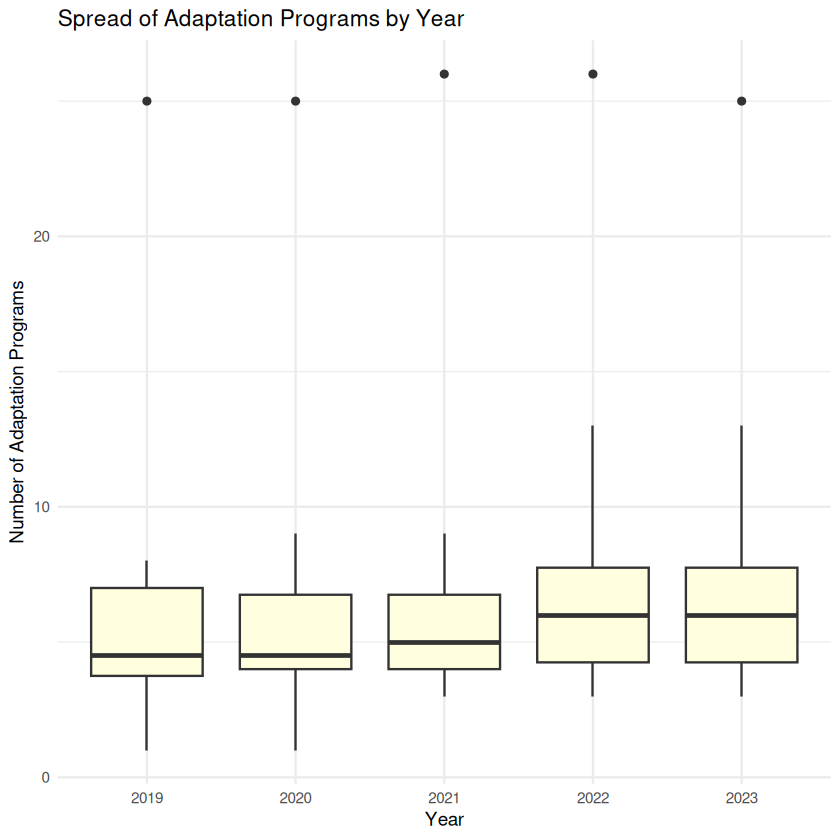

In [29]:
# Boxplot: adaptation programs by year
ggplot(df, aes(x = as.factor(CDP_response_year), y = num_adapt_programs)) +
  geom_boxplot(fill = "lightyellow") +
  labs(
    title = "Spread of Adaptation Programs by Year",
    x = "Year",
    y = "Number of Adaptation Programs"
  ) +
  theme_minimal()

**Interpretation:** In contrast to hazards, adaptation program counts show a gradual upward trend in median values across the reporting period, rising from approximately 4 in 2019–2020 to approximately 5–6 by 2022–2023. The interquartile range also shifts upward over time, spanning roughly 3 to 6 in earlier years and widening to approximately 5 to 7 by 2022, indicating that the increase in programming was broad\-based rather than driven by a small number of high\-performing cities. A consistent high outlier near 25–26 programs appears in every year, almost certainly representing the same city \(Columbus, Ohio\) which reported unusually high adaptation program counts throughout the dataset. The upward movement in median values alongside a stable spread suggests that cities are collectively and steadily expanding their climate adaptation efforts over time, independent of the outlier, pointing to a genuine systemic increase in municipal climate programming across this five\-year period.


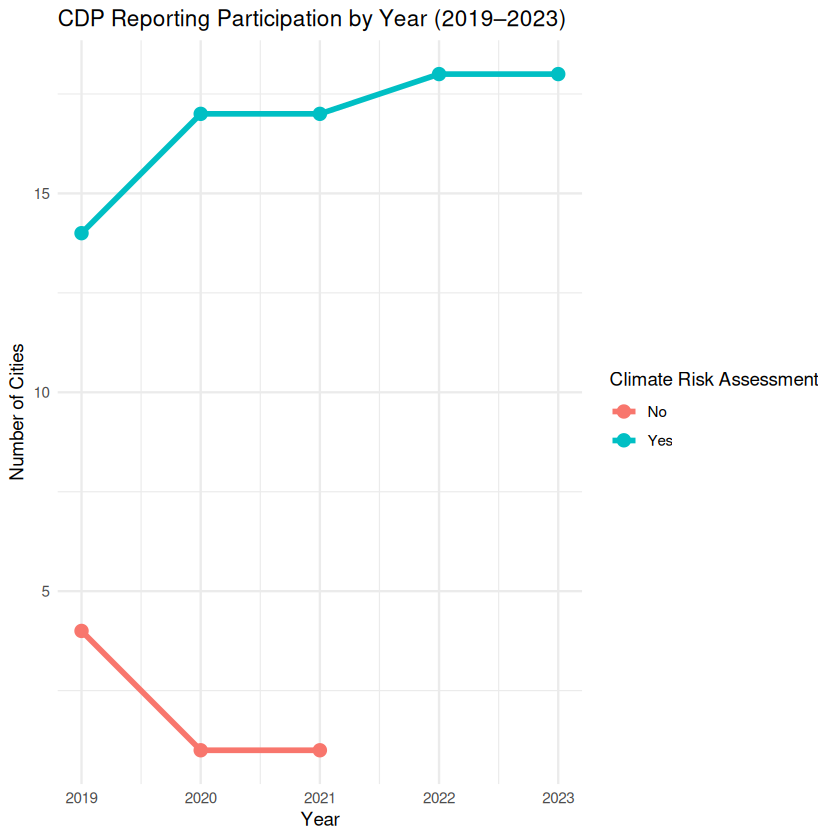

In [12]:
# Count cities reporting each year (climate risk assessment = Yes vs No)
participation <- df %>%
  group_by(CDP_response_year, climate_risk_assessment_YN) %>%
  summarise(count = n(), .groups = "drop")

# Plot: Participation trend over time
ggplot(participation, aes(x = CDP_response_year, y = count, color = climate_risk_assessment_YN)) +
  geom_line(linewidth = 1.2) +
  geom_point(size = 3) +
  labs(
    title = "CDP Reporting Participation by Year (2019–2023)",
    x = "Year",
    y = "Number of Cities",
    color = "Climate Risk Assessment"
  ) +
  theme_minimal()

**Interpretation:** The line chart shows a clear increase in formal climate risk assessment completion over the reporting period. In 2019, four cities had not completed a climate risk assessment. By 2022 and 2023, all 18 cities reported completing one, suggesting that climate risk assessments have become an increasingly expected institutional practice among major U.S. cities. 


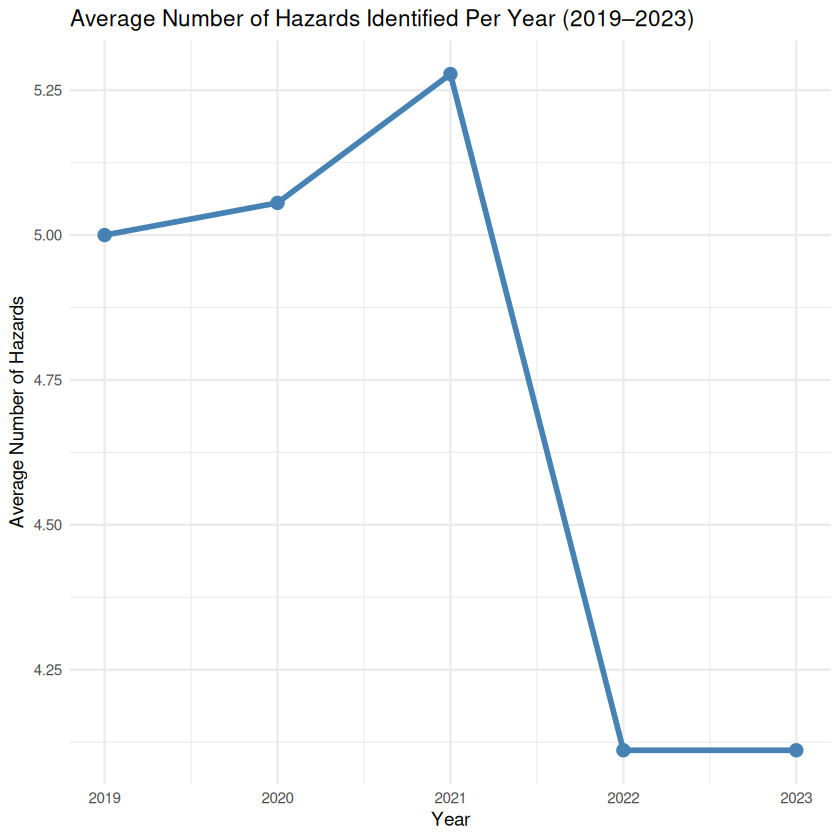

In [13]:
# Average hazards identified per year
hazard_trend <- df %>%
  group_by(CDP_response_year) %>%
  summarise(avg_hazards = mean(num_hazards, na.rm = TRUE), .groups = "drop")

ggplot(hazard_trend, aes(x = CDP_response_year, y = avg_hazards)) +
  geom_line(color = "steelblue", linewidth = 1.2) +
  geom_point(size = 3, color = "steelblue") +
  labs(
    title = "Average Number of Hazards Identified Per Year (2019–2023)",
    x = "Year",
    y = "Average Number of Hazards"
  ) +
  theme_minimal()

**Interpretation:** Average hazards identified per city rose slightly from 5 in 2019 to a peak of ~5.28 in 2021, then dropped sharply to 4.11 in 2022 and remained flat through 2023. The post\-2021 decline is the most notable feature of this trend and is statistically confirmed by the time\-trend regression later in the analysis. Whether this reflects genuine changes in hazard management, reporting behavior, or external disruptions such as COVID\-19 is explored further in the COVID\-era analysis section. 


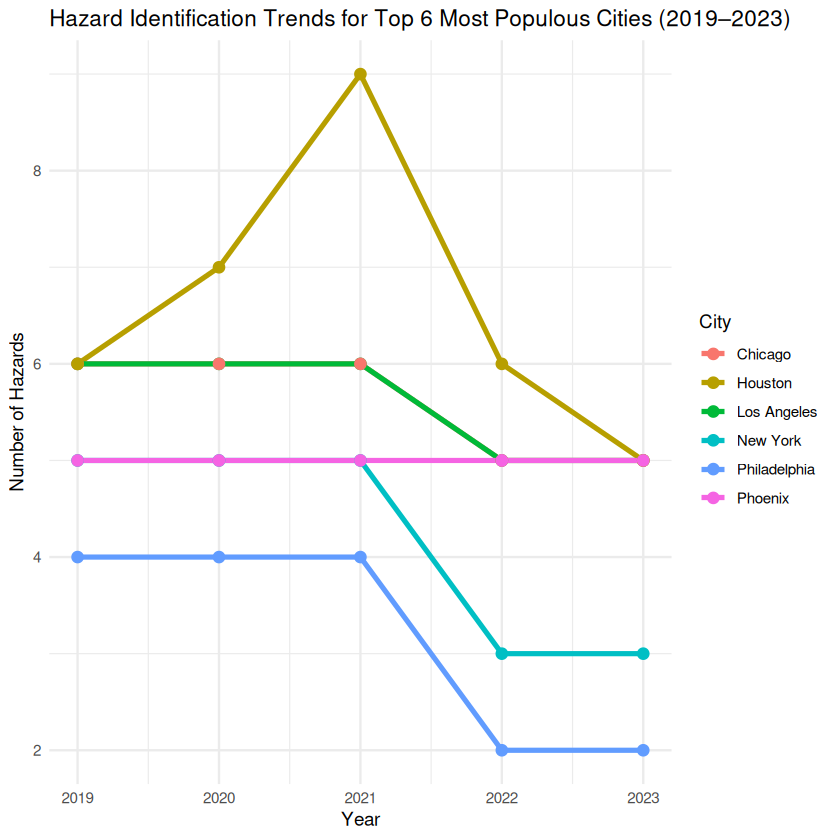

In [43]:
# Per-city hazard trends for top 6 most populous cities
top_cities <- df %>%
  dplyr::filter(CDP_response_year == 2023) %>%
  dplyr::arrange(desc(population)) %>%
  dplyr::slice(1:6) %>%
  dplyr::pull(city)

df %>%
  dplyr::filter(city %in% top_cities) %>%
  ggplot(aes(x = CDP_response_year, y = num_hazards, color = city)) +
  geom_line(linewidth = 1.1) +
  geom_point(size = 2.5) +
  labs(
    title = "Hazard Identification Trends for Top 6 Most Populous Cities (2019–2023)",
    x = "Year",
    y = "Number of Hazards",
    color = "City"
  ) +
  theme_minimal()

**Interpretation:** When examined at the individual city level, the top six most populous cities show considerable variation in hazard identification trajectories. No single city drives the aggregate downward trend as multiple cities show declines from 2021 to 2022, suggesting this pattern is systemic rather than the result of one city's reporting change. New York shows a particularly sharp decline from 5 hazards in 2021 to 3 in 2023, while Los Angeles and Chicago remain relatively stable. This city\-level view adds nuance to the aggregate trend and suggests that the post\-2021 shift affected cities of varying sizes and geographic contexts.


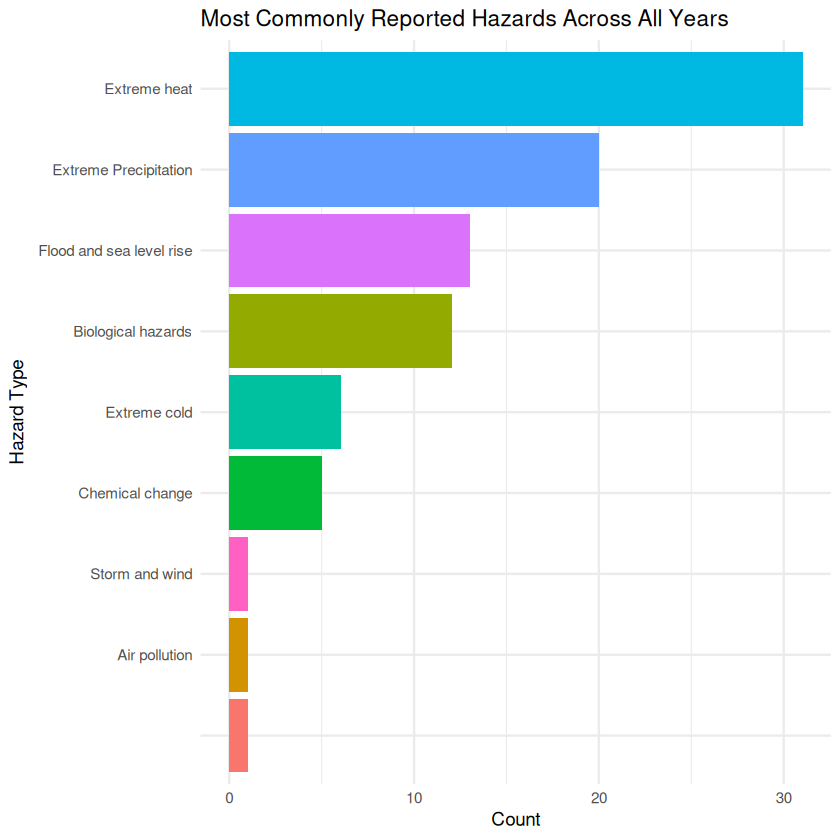

In [14]:
# Count occurrences of each hazard type across all years
hazard_counts <- df %>%
  filter(!is.na(most_common_hazard)) %>%
  group_by(most_common_hazard) %>%
  summarise(count = n(), .groups = "drop") %>%
  arrange(desc(count))

ggplot(hazard_counts, aes(x = reorder(most_common_hazard, count), y = count, fill = most_common_hazard)) +
  geom_bar(stat = "identity", show.legend = FALSE) +
  coord_flip() +
  labs(
    title = "Most Commonly Reported Hazards Across All Years",
    x = "Hazard Type",
    y = "Count"
  ) +
  theme_minimal()

**Interpretation:** Extreme heat is the most frequently reported primary hazard across all cities and years, appearing in over 30 city\-year records, followed by extreme precipitation and flood and sea level rise. Biological hazards, chemical change, extreme cold, storm and wind, and air pollution appear less frequently. This distribution reflects broader national climate trends and suggests that heat and water\-related hazards dominate the urban climate risk landscape among major U.S. cities. The dominance of extreme heat is particularly notable given its association with mortality, infrastructure stress, and disproportionate impacts on vulnerable urban populations.


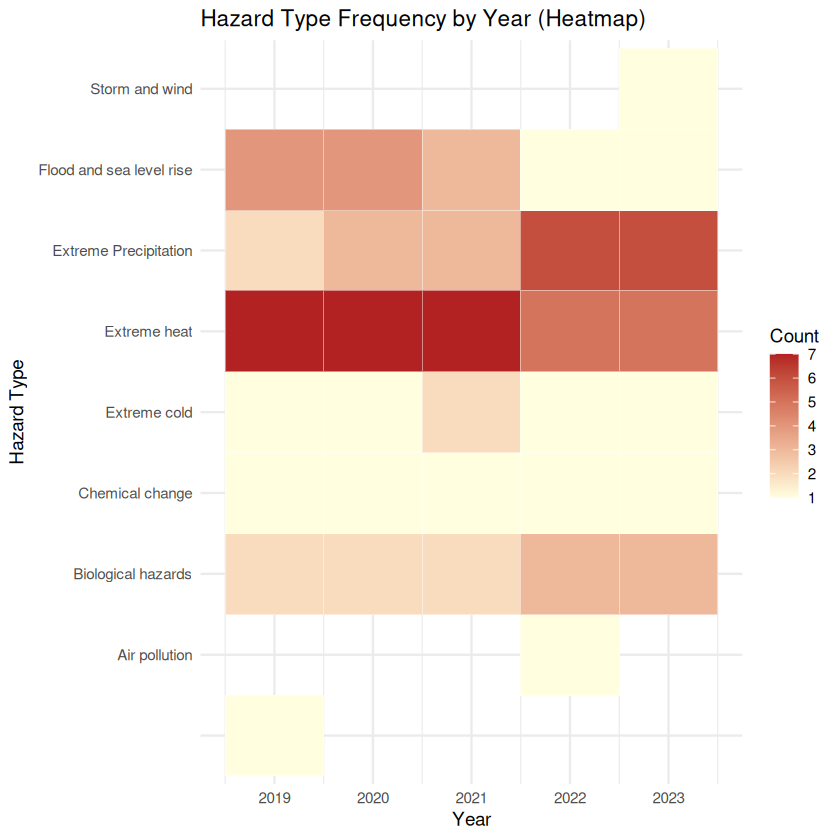

In [15]:
# Count hazard types per year
hazard_year <- df %>%
  filter(!is.na(most_common_hazard)) %>%
  group_by(CDP_response_year, most_common_hazard) %>%
  summarise(count = n(), .groups = "drop")

ggplot(hazard_year, aes(x = CDP_response_year, y = most_common_hazard, fill = count)) +
  geom_tile(color = "white") +
  scale_fill_gradient(low = "lightyellow", high = "firebrick") +
  labs(
    title = "Hazard Type Frequency by Year (Heatmap)",
    x = "Year",
    y = "Hazard Type",
    fill = "Count"
  ) +
  theme_minimal()

**Interpretation:** The heatmap reveals how the frequency of each hazard type as a primary reported hazard changed across years. Extreme heat appears consistently dark across all five years, confirming its dominance throughout the period. Extreme precipitation becomes notably more prominent in 2023. Biological hazards show a slight increase in frequency after 2020, consistent with COVID\-19 raising awareness of health\-related climate risks. Several hazard types such as storm and wind and chemical change appear only sporadically, indicating they are reported as primary hazards by only one or two cities in isolated years.


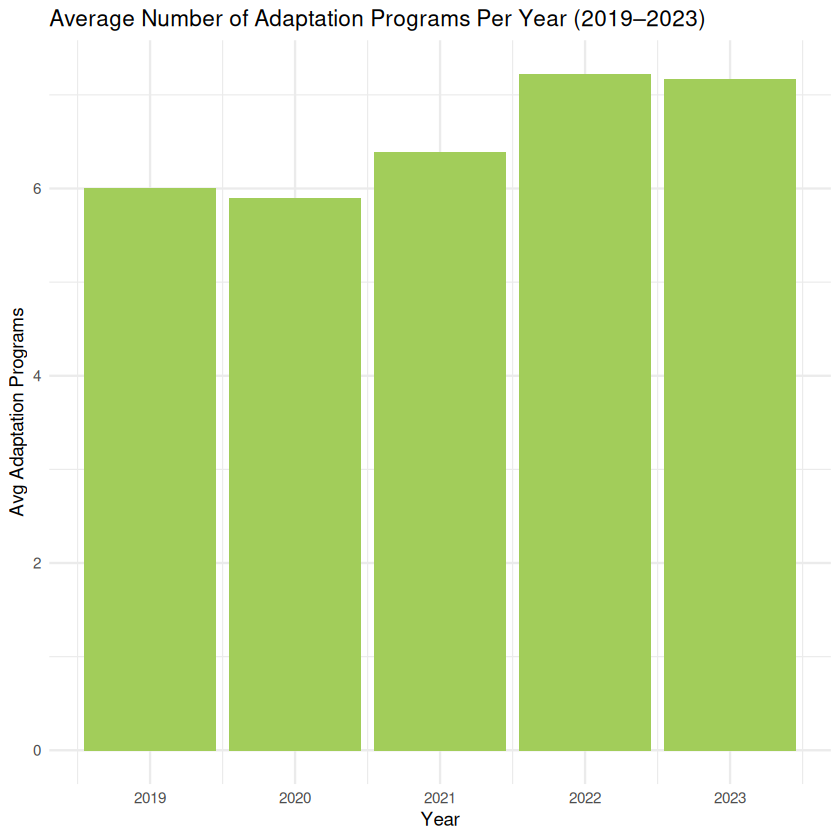

In [16]:
# Average number of adaptation programs per year
adapt_trend <- df %>%
  group_by(CDP_response_year) %>%
  summarise(avg_adapt = mean(num_adapt_programs, na.rm = TRUE), .groups = "drop")

ggplot(adapt_trend, aes(x = CDP_response_year, y = avg_adapt)) +
  geom_bar(stat = "identity", fill = "darkolivegreen3") +
  labs(
    title = "Average Number of Adaptation Programs Per Year (2019–2023)",
    x = "Year",
    y = "Avg Adaptation Programs"
  ) +
  theme_minimal()

**Interpretation:** Average adaptation programs per city dropped slightly from 2019 to 2020 before recovering steadily, reaching a peak of 7.22 in 2022 and holding at 7.17 in 2023. The 2020 dip is modest but consistent with COVID\-19 disrupting city planning operations during the first year of the pandemic. The subsequent growth through 2022 suggests an expansion of adaptation programs efforts. 


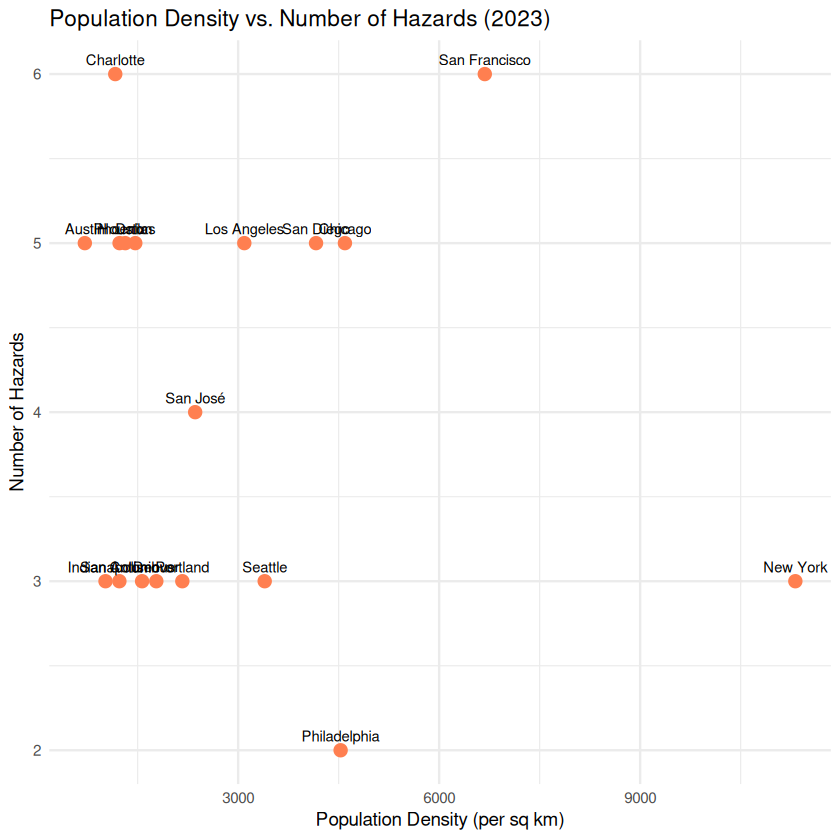

In [46]:
df_2023 <- df %>% filter(CDP_response_year == 2023)

ggplot(df_2023, aes(x = pop_density, y = num_hazards, label = city)) +
  geom_point(color = "coral", size = 3) +
  geom_text(vjust = -0.8, size = 3) +
  labs(
    title = "Population Density vs. Number of Hazards (2023)",
    x = "Population Density (per sq km)",
    y = "Number of Hazards"
  ) +
  theme_minimal()

**Interpretation:** The scatter plot shows no clear linear relationship between population density and number of hazards identified in 2023. Cities are dispersed across the plot with no discernible upward or downward pattern, adn the correlation test confirms this \(r = \-0.10, p = 0.71\). Notably, San Francisco, the densest city in the dataset, reports a moderate number of hazards, while lower\-density cities like Houston and Phoenix report moderate to high counts. This suggests that how dense a city is does not predict how many climate hazards it formally identifies. 


`geom_smooth()` using formula = 'y ~ x'


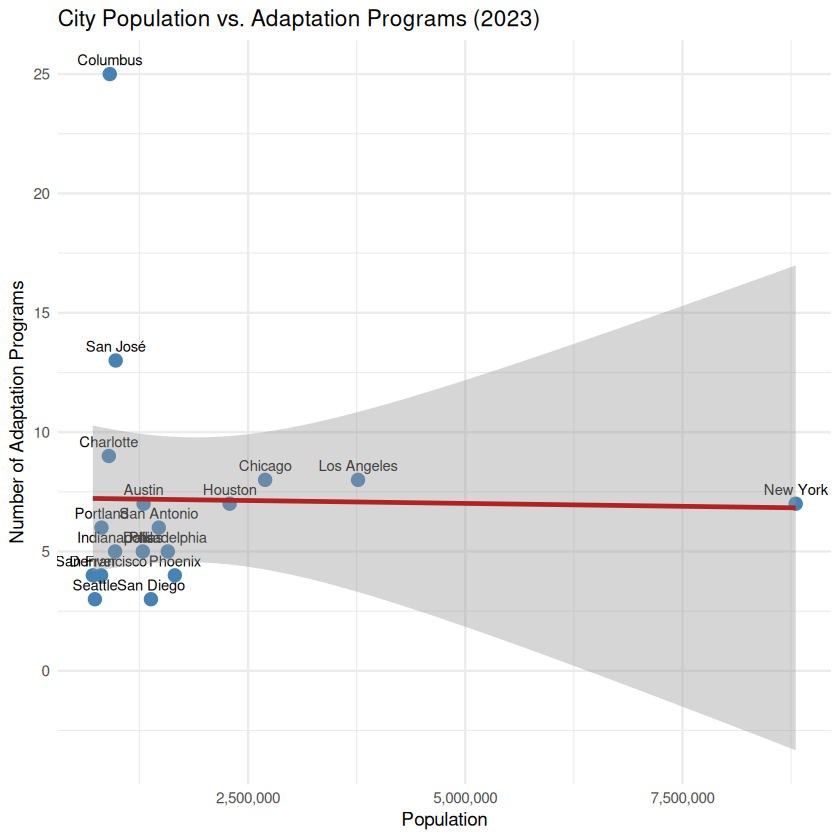

In [31]:
# Population size vs. adaptation programs
ggplot(df_2023, aes(x = population, y = num_adapt_programs)) +
  geom_point(color = "steelblue", size = 3) +
  geom_text(aes(label = city), vjust = -0.8, size = 3) +
  geom_smooth(method = "lm", se = TRUE, color = "firebrick") +
  scale_x_continuous(labels = scales::comma) +
  labs(
    title = "City Population vs. Adaptation Programs (2023)",
    x = "Population",
    y = "Number of Adaptation Programs"
  ) +
  theme_minimal()

**Interpretation:** The scatter plot of city population against adaptation programs shows a flat regression line with wider confidence intervals, consistent with the near\-zero correlation \(r = \-0.02, p = 0.94\). New York is the clear population outlier on the far right but does not stand out as an adaptation outlier, reporting 7 programs, close to the dataset average. This further supports the previous finding that city size is not a meaningful predictor of adaptation program counts among these 18 major U.S. cities. 


`geom_smooth()` using formula = 'y ~ x'


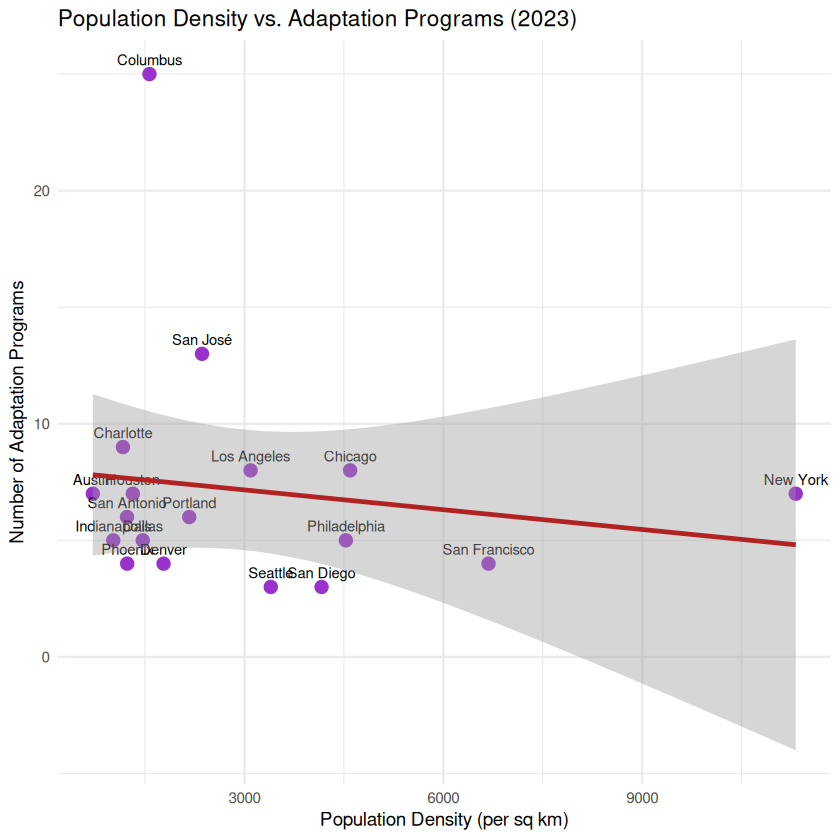

In [33]:
# Population density vs. adaptation programs
ggplot(df_2023, aes(x = pop_density, y = num_adapt_programs)) +
  geom_point(color = "darkorchid", size = 3) +
  geom_text(aes(label = city), vjust = -0.8, size = 3) +
  geom_smooth(method = "lm", se = TRUE, color = "firebrick") +
  labs(
    title = "Population Density vs. Adaptation Programs (2023)",
    x = "Population Density (per sq km)",
    y = "Number of Adaptation Programs"
  ) +
  theme_minimal()

**Interpretation:** Similar to population size, population density shows no meaningful relationship with adaptation program counts \(r = \-0.15, p = 0.56\). The regression line is slightly negative but the confidence band is extremely wide, indicating high uncertainty. San Francisco, the densest city, reports only 4 adaptation programs, below the dataset average, while several lower\-density cities report higher counts. This pattern reinforces the broader finding that city size and density metrics are not strong drivers of adaptation effort in this dataset.


In [34]:
# Correlations: city size metrics vs adaptation
cor.test(df_2023$population, df_2023$num_adapt_programs, use = "complete.obs")
cor.test(df_2023$pop_density, df_2023$num_adapt_programs, use = "complete.obs")
cor.test(df_2023$pop_density, df_2023$num_hazards, use = "complete.obs")


	Pearson's product-moment correlation

data:  df_2023$population and df_2023$num_adapt_programs
t = -0.072924, df = 16, p-value = 0.9428
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.4810047  0.4524928
sample estimates:
        cor 
-0.01822799 



	Pearson's product-moment correlation

data:  df_2023$pop_density and df_2023$num_adapt_programs
t = -0.59318, df = 16, p-value = 0.5614
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.5742340  0.3437192
sample estimates:
       cor 
-0.1466906 



	Pearson's product-moment correlation

data:  df_2023$pop_density and df_2023$num_hazards
t = -0.38233, df = 16, p-value = 0.7073
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.5381139  0.3890025
sample estimates:
       cor 
-0.0951477 


<span style='font-size:small'>**Interpretation: City Size and Density Analysis**</span>

To address the second part of my research question, how city size and population density relate to hazard exposure, I examined 2023 values as a cross\-sectional snapshot in time. Three Pearson correlation tests assess whether larger or denser cities systematically differ in their climate reporting and adaptation behavior.

All three correlations were found to be near zero and statistically non\-significant:

- Population vs. adaptation: r = \-0.02, p = 0.94
- Population density vs. adaptation programs: r = 0.15, p = 0.56
- Population density vs. number of hazards: r = \-0.10, p = 0.71

None of these results meet the threshold for statistical significance \(p &lt; 0.05\), meaning it cannot be concluded that larger or denser cities implement more adaptation programs or identify more hazards than smaller or less dense cities. The slightly negative direction of all three correlations is noteworthy but should not be over\-interpreted given the small sample size of 18 cities and wide confidence intervals in all tests.

These findings suggest that city size alone does not determine climate adaptation efforts. Other factors not evaluated, like institutional capacity, political will, access to federal funding, or regional climate exposure may be more influential drivers than population metrics. 

Note: Because population and land area were standardized to 2023 values, city size and density function as fixed city\-level charactistics in this dataset. The corrections above are therefore cross\-sectional comparisons across cities rather than a time series. 


In [18]:
# Summary stats table: by year
df %>%
  group_by(CDP_response_year) %>%
  summarise(
    cities_reporting = n(),
    avg_hazards = round(mean(num_hazards, na.rm = TRUE), 2),
    avg_adapt_programs = round(mean(num_adapt_programs, na.rm = TRUE), 2),
    pct_assessed = round(mean(climate_risk_assessment_YN == "Yes") * 100, 1))

CDP_response_year,cities_reporting,avg_hazards,avg_adapt_programs,pct_assessed
<int>,<int>,<dbl>,<dbl>,<dbl>
2019,18,5.00,6.00,77.8
2020,18,5.06,5.89,94.4
2021,18,5.28,6.39,94.4
2022,18,4.11,7.22,100.0
2023,18,4.11,7.17,100.0


In [19]:
# Pearson correlation between number of hazards and adaptation programs
cor_test <- cor.test(df$num_hazards, df$num_adapt_programs, use = "complete.obs")
print(cor_test)


	Pearson's product-moment correlation

data:  df$num_hazards and df$num_adapt_programs
t = 0.65707, df = 86, p-value = 0.5129
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.1408506  0.2760329
sample estimates:
       cor 
0.07067663 



r = 0.071 \- This is a very weak positive correlation. Cities with more self reported hazards trends very slightly toward more adaptation programs, but the relationship is nearly flat. 

p\-value = 0.513 \- This is well above 0.05, meaning the result is not statistically significant. 

**Interpretation:** 

A Pearson correlation test found no statistically significant relationship between the number of hazards identified and the number of adaptation programs reported. This suggests that cities do not necessarily respond to higher hazard counts with proportionally more adaptation initiatives. 


In [20]:
# Correlation by year — does the relationship strengthen over time?
df %>%
  group_by(CDP_response_year) %>%
  summarise(
    correlation = cor(num_hazards, num_adapt_programs, use = "complete.obs"),
    .groups = "drop"
  )

CDP_response_year,correlation
<int>,<dbl>
2019,0.25301137
2020,0.26139473
2021,0.22587798
2022,-0.07686295
2023,-0.11600399


**Interpretation:**

When examined by year, the correlation between hazard identification and adaptation programs shifted from weakly positive in 2019 \(r = 0.25\) to slightly negative by 2023 \(r = \-0.12\). This suggests in earlier reporting years, cities identifying more hazards did tend to report more programs. However, by 2022\-2023, this pattern reveresed, potentially indicating that cities with fewer identified hazards caught up in program development, or that adaptation efforts became more standardized across major U.S. cities regardless of hazard count. 


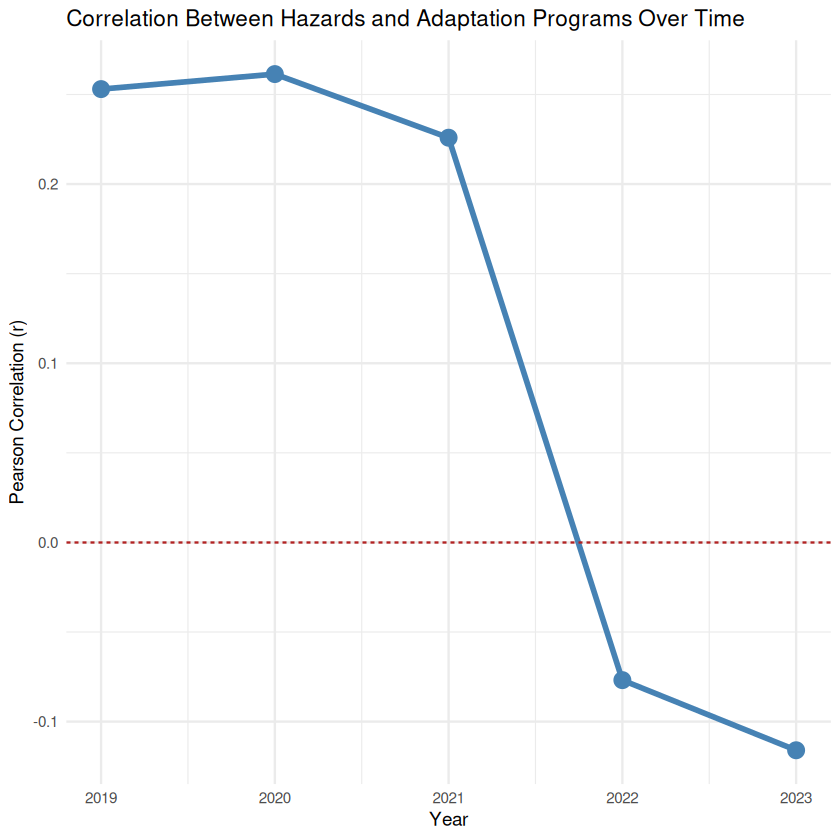

In [21]:
# Create the by-year correlation table as a data frame
cor_by_year <- df %>%
  group_by(CDP_response_year) %>%
  summarise(
    correlation = cor(num_hazards, num_adapt_programs, use = "complete.obs"),
    .groups = "drop"
  )

# Plot correlation trend over time
ggplot(cor_by_year, aes(x = CDP_response_year, y = correlation)) +
  geom_line(linewidth = 1.2, color = "steelblue") +
  geom_point(size = 4, color = "steelblue") +
  geom_hline(yintercept = 0, linetype = "dashed", color = "firebrick") +
  labs(
    title = "Correlation Between Hazards and Adaptation Programs Over Time",
    x = "Year",
    y = "Pearson Correlation (r)"
  ) +
  theme_minimal()

<span style='font-size:small'>**Interpretation: Statistical Analysis \- Regression and ANOVA**</span>

To move beyond correlation and examine predictive relationships, linear regression and analysis of variance \(ANOVA\) can be applied. The multiple regression model tests whether hazard count, population density, and reporting year together predict the number of adaptation programs a city implements. The time\-trend regression tests whether hazard identification has changed significantly over the 2019\-2023 reporting period. The ANOVA tests whether cities facing different primary hazard types differ meaningfully in their adaptation program counts, which speaks to whether hazard type, not just hazard count, influences city climate responses. 


In [35]:
# Multiple regression: what prediction adaptation programs?
model_full <- lm(num_adapt_programs ~ num_hazards + pop_density + 
                   CDP_response_year, data = df)
summary(model_full)


Call:
lm(formula = num_adapt_programs ~ num_hazards + pop_density + 
    CDP_response_year, data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-5.1607 -2.6006 -1.3531  0.6001 19.3208 

Coefficients:
                    Estimate Std. Error t value Pr(>|t|)
(Intercept)       -9.675e+02  8.222e+02  -1.177    0.243
num_hazards        4.014e-01  3.994e-01   1.005    0.318
pop_density       -2.510e-04  2.123e-04  -1.182    0.240
CDP_response_year  4.814e-01  4.066e-01   1.184    0.240

Residual standard error: 5.126 on 84 degrees of freedom
  (2 observations deleted due to missingness)
Multiple R-squared:  0.03685,	Adjusted R-squared:  0.002452 
F-statistic: 1.071 on 3 and 84 DF,  p-value: 0.3658


**Interpretation:** The multiple regression model found that hazard count, population density, and reporting year together explain only 3.7% of the variance in adaptation programs \(R² = 0.037, F = 1.07, p = 0.37\). None of the three predictors were statistically significant individually, suggesting that these variables alone do not reliably predict how many adaptation programs a city implements. This reinforces the earlier correlation findings and points to unmeasured factors, such as city budget, political context, or federal funding access, as potentially stronger drivers of adaptation program counts.


In [36]:
# Trend regression: are hazards changing significantly over time?
model_time <- lm(num_hazards ~ CDP_response_year, data = df)
summary(model_time)


Call:
lm(formula = num_hazards ~ CDP_response_year, data = df)

Residuals:
    Min      1Q  Median      3Q     Max 
-2.4389 -1.1637  0.0108  0.8363  4.2860 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)   
(Intercept)       560.8117   209.8752   2.672  0.00900 **
CDP_response_year  -0.2752     0.1038  -2.650  0.00957 **
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.377 on 87 degrees of freedom
  (1 observation deleted due to missingness)
Multiple R-squared:  0.07467,	Adjusted R-squared:  0.06404 
F-statistic: 7.021 on 1 and 87 DF,  p-value: 0.009569


**Interpretation:** The time trend regression found that hazard identification declined significantly over the reporting period \(slope = \-0.28 hazards/year, p = 0.010\). While the model explains only 7.5% of the variance \(R² = 0.075\), the statistically significant negative slope confirms that the downward trend observed in average hazards after 2021 is not due to chance. This is one of the strongest statistical findings in this analysis, suggesting a genuine shift in how cities are formally reporting climate hazards over time. This will be further explored in later sections on potential COVID\-era impacts on climate hazard reporting.


In [39]:
# ANOVA: do adaptation programs differ by most common hazard type?
anova_model <- aov(num_adapt_programs ~ most_common_hazard, data = df)
summary(anova_model)

                   Df Sum Sq Mean Sq F value Pr(>F)
most_common_hazard  7  199.2   28.46   1.088  0.379
Residuals          80 2092.6   26.16               
2 observations deleted due to missingness

**Interpretation:** The one\-way ANOVA found no statistically significant difference in adaptation program counts across hazard types \(F = 1.09, p = 0.38\). While the boxplot below suggests visual differences between groups, particularly between extreme heat and biological hazard cities, these differences are not large enough relative to within\-group variability to reach significance with this sample size. This result should be interpreted cautiously, as the small number of observations per hazard category limits statistical power.


Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_boxplot()`).”


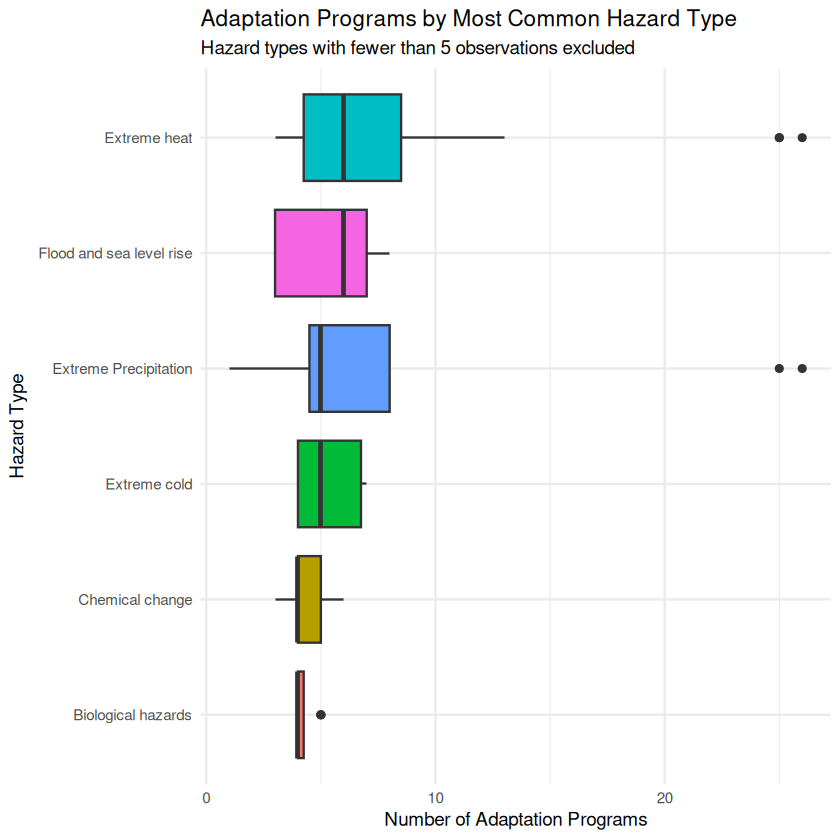

In [42]:
# Visualize: adaptation programs by hazard type - do cities that face different primary hazard types rend to run different nummbers of adaptation progrms? 
# Identify hazard types with enough observations to plot meaningfully
hazard_counts_filter <- df %>%
  dplyr::filter(!is.na(most_common_hazard)) %>%
  dplyr::group_by(most_common_hazard) %>%
  dplyr::summarise(n = n(), .groups = "drop") %>%
  dplyr::filter(n >= 5)

# Plot only hazard types with 5 or more observations
df %>%
  dplyr::filter(most_common_hazard %in% hazard_counts_filter$most_common_hazard) %>%
  ggplot(aes(x = reorder(most_common_hazard, num_adapt_programs, median),
             y = num_adapt_programs,
             fill = most_common_hazard)) +
  geom_boxplot(show.legend = FALSE) +
  coord_flip() +
  labs(
    title = "Adaptation Programs by Most Common Hazard Type",
    subtitle = "Hazard types with fewer than 5 observations excluded",
    x = "Hazard Type",
    y = "Number of Adaptation Programs"
  ) +
  theme_minimal()

**Interpretation:** Cities where extreme heat is the primary hazard show the highest median adaptation program count and the widest spread, including two high outliers. Biological hazard cities show the lowest median and narrowest range. Flood, extreme precipitation, and extreme cold cities fall in the middle with moderate and relatively consistent program counts. Overall, hazard types appear associated with differences in adaptation efforts, providing insight into the difference in robustness associated with adaptation needs of different hazards. This is significant because it directly addresses the research question of whether hazard exposure influences adaptation implementation, indicating that what kind of hazard a city faces may matter as much as how many hazards it identifies. 


In [22]:
library(dplyr)
library(ggplot2)

<span style='font-size:large'>**COVID\-19 Era Analysis**</span>

The COVID\-19 pandemic beginning in 2020 represented an unprecedented disruption to municipal operations across the United States. City governments faced sudden reallocation of budgets, staffing, and political attention towards public health emergency reponse, raising the question of whether climate\-related reporting and adaptation efforts were affected during this period. 

This section examines whether the pandemic, which falls within the five\-year reporting period evaluated in this dataset, left a detectable impact in CDP reporting data by comparing adaptation program counts and hazard identification rates before, during, and after the initial COVID\-19 period. Because this dataset does not include budget, staffing, or other possible impactful variables, any COVID\-related patterns are observational and correlational rather than causal, but meaningful trends can still be identified and interpreted in the context of what is known about municipal responses to the pandemic. 


In [23]:
# Adaptation programs before and after COVID
df %>%
  dplyr::group_by(CDP_response_year) %>%
  dplyr::summarise(avg_programs = mean(num_adapt_programs, na.rm = TRUE), .groups = "drop")

CDP_response_year,avg_programs
<int>,<dbl>
2019,6.000000
2020,5.888889
2021,6.388889
2022,7.222222
2023,7.166667


In [24]:
df %>%
  dplyr::group_by(CDP_response_year) %>%
  dplyr::summarise(avg_hazards = mean(num_hazards, na.rm = TRUE), .groups = "drop")

CDP_response_year,avg_hazards
<int>,<dbl>
2019,5.000000
2020,5.055556
2021,5.277778
2022,4.111111
2023,4.111111


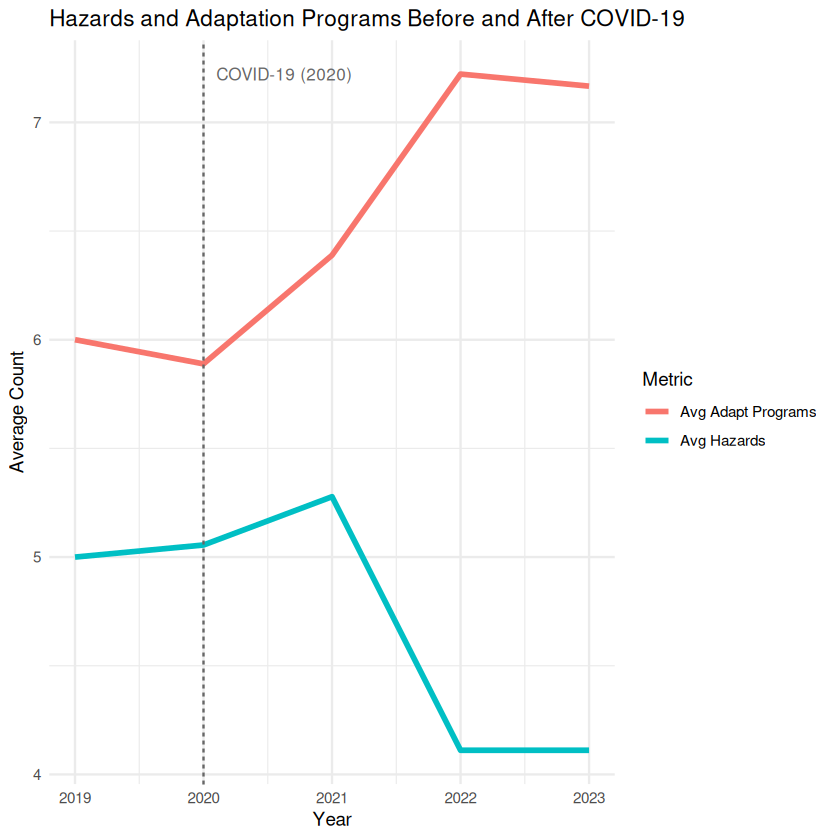

In [25]:
# Visualize number of hazard adaptation programs before and after COVID

library(ggplot2)

yearly_summary <- df %>%
  dplyr::group_by(CDP_response_year) %>%
  dplyr::summarise(
    avg_hazards = mean(num_hazards, na.rm = TRUE),
    avg_programs = mean(num_adapt_programs, na.rm = TRUE),
    .groups = "drop"
  )

ggplot(yearly_summary, aes(x = CDP_response_year)) +
  geom_line(aes(y = avg_hazards, color = "Avg Hazards"), linewidth = 1.2) +
  geom_line(aes(y = avg_programs, color = "Avg Adapt Programs"), linewidth = 1.2) +
  geom_vline(xintercept = 2020, linetype = "dashed", color = "gray40") +
  annotate("text", x = 2020.1, y = max(yearly_summary$avg_programs, na.rm = TRUE),
           label = "COVID-19 (2020)", hjust = 0, size = 3.5, color = "gray40") +
  labs(
    title = "Hazards and Adaptation Programs Before and After COVID-19",
    x = "Year",
    y = "Average Count",
    color = "Metric"
  ) +
  theme_minimal()

**Interpretation:**

Adaptation program counts dipped slightly in 2020, consistent with COVID\-19 era disruptions to city planning, but recovered and surpassed pre\-pandemic levels by 2022. This suggests that institutional commitments to climate adaptation remained intact despite the pandemic, with cities increasingly programming in the post\-COVID period. 

After 2021, average hazards identified dropped sharply and then stayed flat. This inverse relationship between adaptation programs and climate hazard identification suggests that by 2022, cities were running more climate initiatives despite formally identifying fewer hazards. This may reflect a few things: a maturation of climate policy in which cities no longer need to identify new hazards to justify expanding programs as adaptation became institutionalized into city planning, cities becoming more selective in hazard reporting over time by refining or consolidating their assessments, or external policy momentum such as increased federal climate funding post\-2021 enabling cities to expand adaptation programming independent of local hazard assessment cycles. Further analysis incorporating city budget or federal grant data would be needed to confirm which mechanism is most responsible for this divergence. 



<span style='font-size:large'>**Final Communication Narrative**</span>


In [44]:
# Final summary table — clean and readable
library(dplyr)

summary_table <- df %>%
  dplyr::group_by(CDP_response_year) %>%
  dplyr::summarise(
    `Cities Reporting` = n(),
    `% With Risk Assessment` = round(
      mean(climate_risk_assessment_YN == "Yes") * 100, 1),
    `Avg Hazards Identified` = round(mean(num_hazards, na.rm = TRUE), 2),
    `Avg Adaptation Programs` = round(
      mean(num_adapt_programs, na.rm = TRUE), 2),
    .groups = "drop"
  ) %>%
  dplyr::rename(Year = CDP_response_year)

print(summary_table)

# A tibble: 5 × 5
   Year `Cities Reporting` `% With Risk Assessment` `Avg Hazards Identified`
  <int>              <int>                    <dbl>                    <dbl>
1  2019                 18                     77.8                     5   
2  2020                 18                     94.4                     5.06
3  2021                 18                     94.4                     5.28
4  2022                 18                    100                       4.11
5  2023                 18                    100                       4.11
# ℹ 1 more variable: `Avg Adaptation Programs` <dbl>


<span style='font-size:medium'>**Summary and Conclusions**</span>

<span style='font-size:small'>This analysis examined how 18 of the most populous U.S. cities reported climate hazards and implemented adaptation programs through the CDP Cities Survey from 2019 to 2023.</span>

<span style='font-size:small'>**Key Findings:**</span>

1. <span style='font-size:small'>Growing institutional engagement: The share of cities completing a formal climate risk assessment rose from 78% in 2019 to 100% by 2022, suggesting that climate risk assessment has become a standard practice among major U.S. cities over this period.</span>
2. <span style='font-size:small'>Hazards and programs are decoupling: Overall, there was no statistically significant correlation between the number of hazards a city identified and the number of adaptation programs it ran \(r = 0.07, p = 0.51\). More strikingly, this relationship shifted from weakly positive in 2019–2021 to slightly negative by 2023, suggesting that adaptation programming is increasingly driven by factors beyond local hazard counts —such as federal funding, policy mandates, or institutional capacity.</span>
3. <span style='font-size:small'>COVID\-era disruption and recovery: Adaptation programs dipped slightly in 2020 before recovering strongly. Hazard identification peaked in 2021 and then declined sharply, creating a visible divergence between the two metrics in the post\-pandemic period.</span>
4. <span style='font-size:small'>Extreme heat dominates: Extreme heat was the most frequently reported primary hazard across all cities and years, followed by extreme precipitation and flooding, reflecting broader national trends in climate risk.</span>

<span style='font-size:small'>**Limitations**</span>

1. <span style='font-size:small'>Population, land area, and density were standardized to 2023 values and applied uniformly across all years. This simplification assumes these are stable characteristics, which limits analysis of how city growth may have influenced climate reporting over time.</span>
2. <span style='font-size:small'>The dataset covers only 18 large U.S. cities. Findings are not generalizable to smaller or mid\-sized municipalities, which may face different resource constraints and reporting cultures.</span>
3. <span style='font-size:small'>The COVID\-19 interpretation is observational. The dataset does not contain budget, staffing, or public health variables that would confirm a causal link between the pandemic and changes in reporting behavior.</span>
4. <span style='font-size:small'>The most\_common\_hazard variable captures only the single top hazard per city per year, which may underrepresent multi\-hazard exposure in complex urban environments.</span>
5. <span style='font-size:small'>CDP reporting is voluntary and self\-reported, which may introduce reporting bias — cities with stronger climate programs may be more likely to participate, potentially skewing results toward higher adaptation counts.</span>

